Found 1 seed(s) in 'forElaf':
  - pySC_petra4_07_seed10.json

Processing seed: pySC_petra4_07_seed10.json

=== Correction iteration 1/1 ===

 Before LOCO_correction iteration 1
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :  62.3536 µm
RMS vertical orbit           :  57.0595 µm
RMS horizontal beta beating  :  64.6990 %
RMS vertical beta beating    :  40.8097 %
RMS horizontal dispersion err:  41.6386 mm
RMS vertical dispersion err  :  14.6472 mm
Ideal Tune                         : [135.18050254128747, 86.27059102835547, 0.004823007274348343]
Ideal Chromaticity                 : [8.129033564100263, 7.313412029674923, 0.003287773033764023]
Tune                               : [135.18155497426488, 86.27061640058773, 0.0048337106290069175]
Chromaticity                       : [3.091781166642789, 2.536477903457061, 0.0026841872036359716]
Ideal emittance_h 19.795812447996422 emittance_v 0.0
With errors emittance_h 393.91867916146975 emit

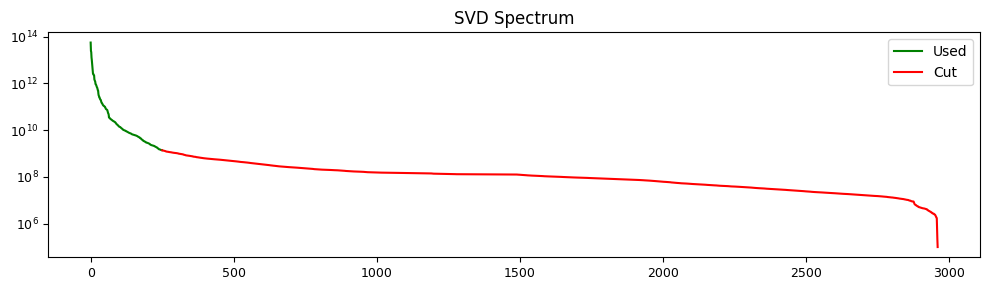

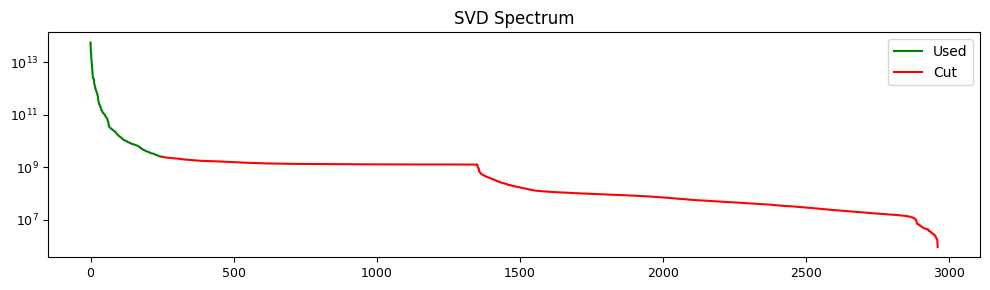

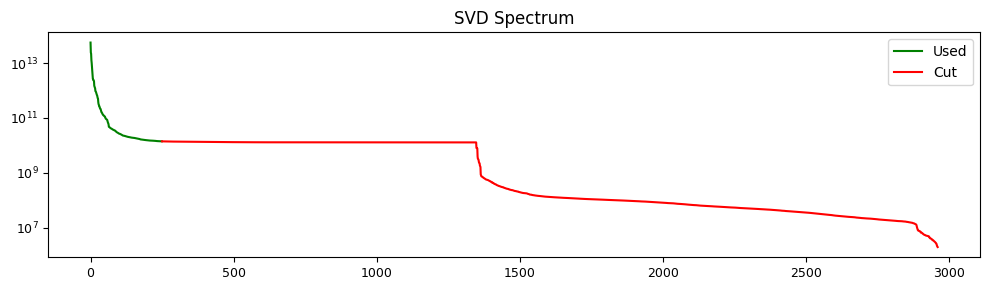

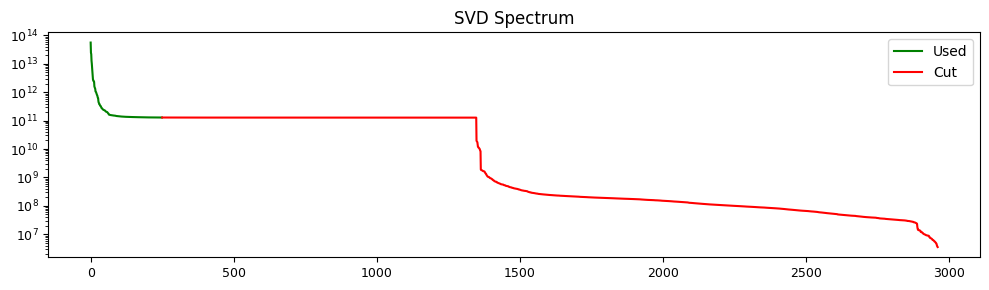

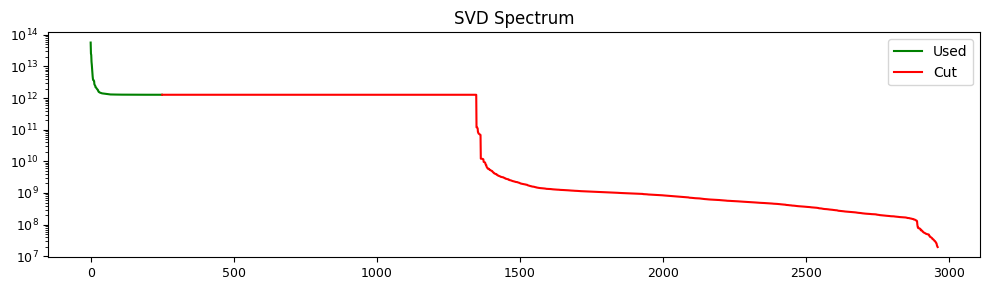

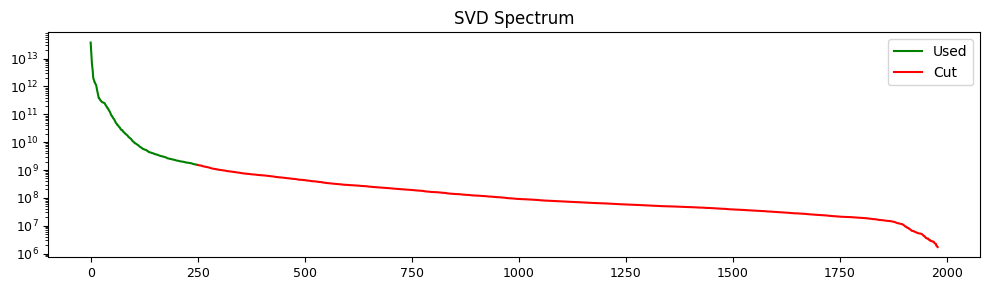

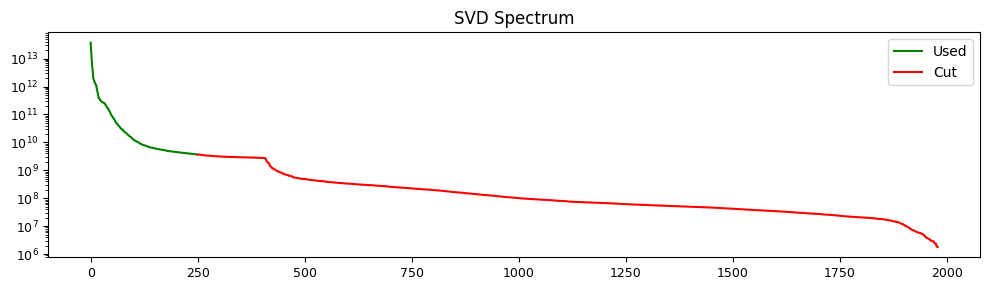

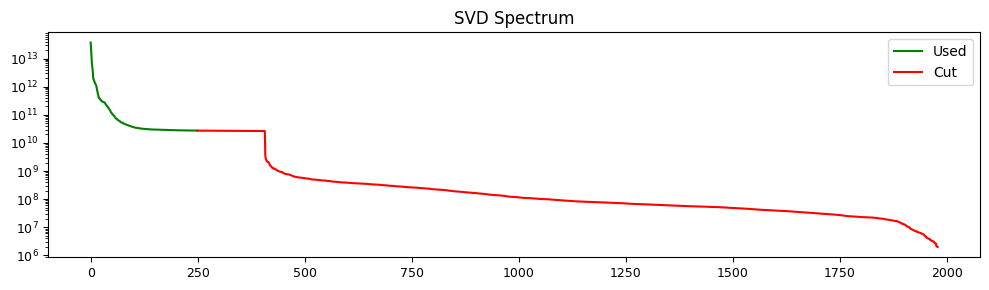

[info] Wrote log to After_pyLOCO/pySC_petra4_07_seed10_loco_iteration.log
--------
 After LOCO quadrupoles correction iteration 1 ------
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :  62.7490 µm
RMS vertical orbit           :  57.0831 µm
RMS horizontal beta beating  :  20.2731 %
RMS vertical beta beating    :  17.6289 %
RMS horizontal dispersion err:  24.8087 mm
RMS vertical dispersion err  :  11.2841 mm
Ideal Tune                         : [135.18050254128747, 86.27059102835547, 0.004823007274348343]
Ideal Chromaticity                 : [8.129033564100263, 7.313412029674923, 0.003287773033764023]
Tune                               : [135.2175196302819, 86.26864956956854, 0.004826466064323476]
Chromaticity                       : [1.264134713644696, 2.0632116726340715, 0.003723055586099826]
Ideal emittance_h 19.795812447996422 emittance_v 0.0
With errors emittance_h 201.99792051617746 emittance_v 36.314480212703735
---------------

In [1]:
from __future__ import annotations
from pathlib import Path
import traceback
import sys
import at
import time
from pySC import disable_pySC_rich
from pySC.configuration.generation import generate_SC
from pySC.tuning.response_measurements import measure_OrbitResponseMatrix
from pySC.tuning.response_measurements import measure_RFFrequencyOrbitResponse
from pySC.tuning.averaging import get_average_orbit
from pyLOCO.pyloco import remove_bad_bpms, pyloco,last_by_sorted_key, get_quads_block, save_fit_dict, get_fit_param_block
from pyLOCO.analysis import plot_orm_bars_simone_style, plot_beta, plot_eta, plot_matrices
from pyLOCO.response_matrix import response_matrix
from pyloco_config import FitInitConfig, RMConfig, fixed_parameters, loco_options
from set_correction import set_correction
from analyze_ring import analyze_ring
import numpy as np
from for_script import *
import warnings, io, contextlib
from run_pyloco_from_model import run_pyloco_from_model
from at import get_refpts
from pySC import SimulatedCommissioning

disable_pySC_rich()

# _____________________
INPUT_DIR = Path("forElaf")
OUTPUT_DIR = Path("After_pyLOCO")
FILE_PATTERNS = ["*.json"]
SAVE_MAT_KEY = "ring"
MAX_SEEDS = 1

# --------------------
# MAIN
# --------------------
def main():
    if not INPUT_DIR.exists():
        raise FileNotFoundError(f"Input folder not found: {INPUT_DIR.resolve()}")

    seed_files = find_seed_files(INPUT_DIR, FILE_PATTERNS)
    if not seed_files:
        print(f"No seed files matching {FILE_PATTERNS} found in {INPUT_DIR.resolve()}")
        return

    if MAX_SEEDS is not None:
        seed_files = seed_files[:MAX_SEEDS]

    print(f"Found {len(seed_files)} seed(s) in '{INPUT_DIR}':")
    for f in seed_files:
        print(f"  - {f.name}")

    t0_all = time.perf_counter()

    for seed in seed_files:
        seed_dir = OUTPUT_DIR / seed.stem
        seed_dir.mkdir(parents=True, exist_ok=True)

        print("\n" + "=" * 72)
        print(f"Processing seed: {seed.name}")
        t0 = time.perf_counter()

        try:
            warnings.filterwarnings("ignore", category=RuntimeWarning)
            SC = SimulatedCommissioning.from_json('forElaf/pySC_petra4_07_seed10.json', lattice_file='p4_H6BA_v4_3_4_2_for_pySC.mat')

            x0, y0 = SC.bpm_system.capture_orbit()
            SC.bpm_system.reference_x = x0
            SC.bpm_system.reference_y = y0

            used_bpms_ords   = SC.bpm_system.indices  #at.get_refpts(SC.lattice.ring, at.elements.Monitor)
            elements_ind  = at.get_refpts(SC.lattice.ring, "*")

            # --- Pick evenly spread correctors from two families
           # CXYSFA = get_refpts(SC.lattice.ring, 'CXYSFA*')
            CXYSFA = SC.lattice.find_with_regex('^CXYSFA')
            #CXSFB  = get_refpts(SC.lattice.ring, 'CXSFB*')
            CXSFB = SC.lattice.find_with_regex('^CXSFB')
            n_pick = 5
            cxysfa_inds = [CXYSFA[i] for i in np.linspace(0, len(CXYSFA)-1, n_pick, dtype=int)] if len(CXYSFA) else []
            cxsfb_inds  = [CXSFB[i]  for i in np.linspace(0, len(CXSFB)-1,  n_pick, dtype=int)] if len(CXSFB)  else []

            combined_inds = sorted(list(cxysfa_inds) + list(cxsfb_inds))
            if not combined_inds:
                raise RuntimeError("No correctors selected (CXYSFA/CXSFB empty).")

            used_cor_ords = (
                np.asarray(combined_inds, dtype=int),
                np.asarray(combined_inds, dtype=int),
            )

            used_cor_ords = [combined_inds, combined_inds]
            CMstep = [[100e-6] * len(combined_inds),
                      [100e-6] * len(combined_inds)]

            # --- Quads indices for correction block
            quads_indices = get_refpts(SC.lattice.ring, at.elements.Quadrupole)
            magnet_names = SC.magnet_arrays['cysf'] + SC.magnet_arrays['cxysf'] + SC.magnet_arrays['cxsf'] + SC.magnet_arrays['cxysf2']
            skew_quad_indices = sorted([SC.magnet_settings.magnets[magnet_name].sim_index for magnet_name in magnet_names])
            CAVords = at.get_refpts(SC.lattice.ring, at.elements.RFCavity)

            correction_iterations = 1
            for it in range(correction_iterations):
                print(f"\n=== Correction iteration {it + 1}/{correction_iterations} ===")

                print(f'\n Before LOCO_correction iteration {it + 1}')
                analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

                # --- Measurments
                index_mapping = SC.magnet_settings.index_mapping
                HCORR = [index_mapping[cor] + '/B1L' for cor in combined_inds]
                VCORR = [index_mapping[cor] + '/A1L' for cor in combined_inds]
                measured_orm = measure_OrbitResponseMatrix(SC, HCORR, VCORR, dkick = 100e-6, normalize=False, bipolar=True)
                measured_orm[:, 0:10] = measured_orm[:, 0:10] * -1

                #[BPMS x cor] in meter
                eta =  measure_RFFrequencyOrbitResponse(SC, delta_frf =40, normalize = False, bipolar=True)
                measured_eta_x = eta[:len(eta)//2] # meter
                measured_eta_y = eta[len(eta)//2:] # meter
                x, y, x_std, y_std = get_average_orbit(SC, 100)
                sigma_w = np.concatenate((x_std, y_std))  # meter

                #measured_orm = np.hstack((measured_orm, eta.reshape(-1, 1)))

                # --- Run LOCO
                OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
                cap_out, cap_err = io.StringIO(), io.StringIO()
                try:
                    with contextlib.redirect_stdout(cap_out), contextlib.redirect_stderr(cap_err):
                        fit_results, fit_dict, ring_pyloco, fitted_orm,C_bpms_after = run_pyloco_from_model(SC.lattice.design,CMstep, CAVords, quads_indices, skew_quad_indices, used_cor_ords, used_bpms_ords,
                            measured_orm, sigma_w,  measured_eta_x,  measured_eta_y
                        )

                        iter_tag = f"iter_{it+1:02d}"
                        np.savez(
                        seed_dir / f"{iter_tag}_arrays.npz",
                        fitted_orm=fitted_orm,
                        C_bpms_after=C_bpms_after,
                    )

                        import pickle

                        with open(seed_dir / f"{iter_tag}_fit.pkl", "wb") as f:
                            pickle.dump(
                                {
                                    "fit_dict": fit_dict,
                                    "fit_results": fit_results,
                                },
                                f,
                                protocol=pickle.HIGHEST_PROTOCOL,
                            )

                            from scipy.io import savemat

                            savemat(
                                seed_dir / f"{iter_tag}_pyLOCO_model.mat",
                                {"ring": ring_pyloco},
                            )

                except Exception:
                    tb_text = traceback.format_exc()
                    logfile = OUTPUT_DIR / f"{seed.stem}_loco_iteration.log"
                    with open(logfile, "w") as f:
                        f.write(cap_out.getvalue())
                        f.write(cap_err.getvalue())
                        f.write("\n---- TRACEBACK ----\n")
                        f.write(tb_text)
                    raise
                else:
                    logfile = OUTPUT_DIR / f"{seed.stem}_loco_iteration.log"
                    with open(logfile, "w") as f:
                        f.write(cap_out.getvalue())
                        f.write(cap_err.getvalue())
                    print(f"[info] Wrote log to {logfile}")

                # --- Extract quad block and apply correction

                bpm_gain = get_fit_param_block(fit_dict, "hbpm_gain")
                vbpm_gain = get_fit_param_block(fit_dict, "vbpm_gain")
                hbpm_coupling = get_fit_param_block(fit_dict, "hbpm_coupling")
                vbpm_coupling = get_fit_param_block(fit_dict, "vbpm_coupling")
                skew_quads = get_fit_param_block(fit_dict, "skew_quads")
                quads = get_fit_param_block(fit_dict, "quads")
                hcor_cal = get_fit_param_block(fit_dict, "hcor_cal")
                vcor_cal = get_fit_param_block(fit_dict, "vcor_cal")


                delta_q = np.asarray(
                    [quads[i] - SC.lattice.design[quads_indices[i]].K for i in range(len(quads_indices))],
                    dtype=float
                ).ravel()
                set_correction(SC, -delta_q, quads_indices, individuals=True, skewness=False)
                print(f'--------\n After LOCO quadrupoles correction iteration {it + 1} ------')
                SC.lattice.ring.enable_6d()
                SC.lattice.design.enable_6d()
                analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

                delta_skew = np.asarray(
                    [skew_quads[i] - SC.lattice.design[skew_quad_indices[i]].K for i in range(len(skew_quad_indices))],
                    dtype=float
                ).ravel()
                set_correction(SC, - delta_skew, skew_quad_indices, individuals=True, skewness=True)

                print(f'-------- \n After LOCO skew correction iteration {it + 1} --------')
                analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

                # --- Post-correction quick analysis

                analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

                #print('correct orbit and tune')
                #ORM = np.load(f'ORM_ideal.npz')['arr_0']
                #correct_tune_and_orbit(SC, ORM=ORM, alpha=1)
                #_, _, twiss0 = at.get_optics(SC.lattice.design, elements_ind)
                #analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)
                print(f'--------Orbit and Tune correction--------')
                for i in range(1):
                    SC.tuning.correct_orbit(parameter=20)
                    SC.tuning.tune.correct(measurement_method='cheat')
                analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

            saved_path = save_corrected_lattice(SC, seed, OUTPUT_DIR)
            dt = time.perf_counter() - t0
            print(f"Saved to: {Path(saved_path).resolve()}")
            print(f"Time for seed: {dt:.2f} s")

        except Exception as e:
            dt = time.perf_counter() - t0
            tb_text = traceback.format_exc()
            print(f"!! Failed on {seed.name}: {e}")
            print(f"   Time until failure: {dt:.2f} s")
            print("---- TRACEBACK ----")
            print(tb_text)

            OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
            (OUTPUT_DIR / f"{seed.stem}_error.traceback.log").write_text(tb_text)

    total_time = time.perf_counter() - t0_all
    print("\n" + "=" * 72)
    print(f"Done. Seeds processed: {len(seed_files)}  |  Total time: {total_time:.2f} s")

if __name__ == "__main__":
    main()